In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

from brainhack.pulse import Tukey
from brainhack.sequence import Sequence, Modulation
from brainhack.system import System
from brainhack.simulator import Simulator
from brainhack.corrector import Corrector, Correctable

import matplotlib.pyplot as plt
import numpy as np

pulse = Tukey(
    duration = 1e-3,                    # in s
    shape = .3,
    flipAngle = 299,                    # in degree
    offset = 7000                       # in Hz
)

sequence = Sequence(
    modulation = Modulation.BP,
    pulse = pulse,
    N_pulsePerOffset = 1,
    N_pulse = 6,
    N_burst = 10,
    N_adc = 96,
    N_dummyADC = 0,
    dt_interPulse = 1.5e-3,             # in s
    TR_burst = 100e-3,                  # in s
    dt_lastBurst = 9e-3,                # in s
    es = 6e-3,                          # in s
    tr = 20,                            # in s
    readout_flipAngle = 6               # in degree
)

system = System(
    pulse = pulse,
    poolFree_M0 = 1,
    poolBound_M0 = 0.1,
    poolFree_T1 = 1,                    # in s
    poolBound_T1 = 1,                   # in s 
    poolBound_T1D = 0.01,               # in s
    poolFree_T2 = 0.1,                  # in s
    poolBound_T2 = 1e-5,                # in s
    poolFreeBound_exchangeRate = 20     # in s^-1
)

simulator = Simulator(
    system = system,
    sequence = sequence,
    output_vectorSlice = slice(1),
    export_readMatrix = False,
)

# print(simulator.SteadyState())

# nominals = corrector.nominals
simulator.SteadyState()
corrector = Corrector.Simple(simulator)
# print(nominals)
print(corrector.simulated[Correctable.ihMTR_CM].T)

# plt.plot(corrector.mesh['flipAngle'].T, corrector.simulated[Correctable.ihMTR_CM].T, label=corrector.ranges['poolFree_T1'])
# plt.vlines(pulse.flipAngle, 0, 50, 'k', 'dashed')
# plt.legend(title=r'$\mathrm{T}_1^{water}$ [s]')
# plt.xlabel('Flip angle [°]')
# plt.xlim(min(corrector.ranges['flipAngle']), max(corrector.ranges['flipAngle']))
# plt.ylim(0, 50)
# plt.ylabel('ihMTR [%]')
# plt.title(r'Simulated $\mathrm{B}_1^+$ dependencies of ihMTR')
# plt.grid()
# plt.show()

[[34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776 40.96406035]
 [34.66865583 38.68355776

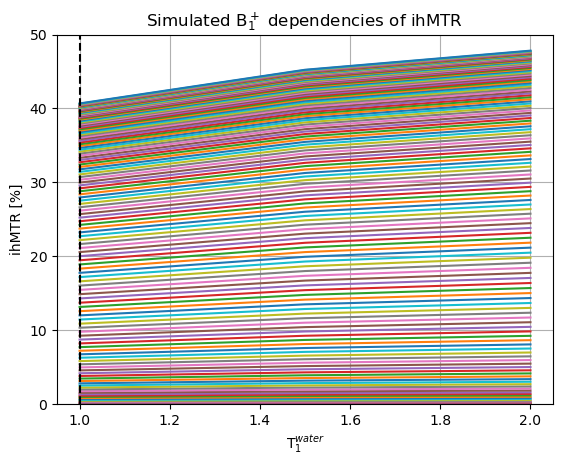

In [4]:
buffer = system.poolFree_T1 * 0.05
plt.plot(corrector.mesh['poolFree_T1'], corrector.simulated[Correctable.ihMTR_CM], label=corrector.ranges['flipAngle'])
plt.vlines(system.poolFree_T1, 0, 50, 'k', 'dashed')
# plt.legend(title=r'$\mathrm{T}_1^{water}$ [s]')
plt.xlabel(r'$\mathrm{T}_1^{water}$')
plt.xlim(min(corrector.ranges['poolFree_T1']) - buffer, max(corrector.ranges['poolFree_T1']) + buffer)
plt.ylim(0, 50)
plt.ylabel('ihMTR [%]')
plt.title(r'Simulated $\mathrm{B}_1^+$ dependencies of ihMTR')
plt.grid()
plt.show()

dict